In [1]:

import seaborn as sns
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/nitheeswaranm/synthetic-wing-spar-digital-twin/fighter_wing_flight_data.csv
/kaggle/input/datasets/nitheeswaranm/synthetic-wing-spar-digital-twin/wing_spar_adjacency.csv


In [2]:
import matplotlib.pyplot as plt

In [3]:
flight_data = pd.read_csv('/kaggle/input/datasets/nitheeswaranm/synthetic-wing-spar-digital-twin/fighter_wing_flight_data.csv')
wing_spar_adjacency = pd.read_csv('/kaggle/input/datasets/nitheeswaranm/synthetic-wing-spar-digital-twin/wing_spar_adjacency.csv')

In [4]:
print(flight_data.columns)
print(wing_spar_adjacency.columns)

Index(['sample_id', 'node_id', 'x_position', 'load_factor_g',
       'deflection_noisy', 'deflection_true'],
      dtype='object')
Index(['source', 'target', 'distance'], dtype='object')


In [5]:
print(flight_data.isna().sum())
print()
print(wing_spar_adjacency.isna().sum())

sample_id           0
node_id             0
x_position          0
load_factor_g       0
deflection_noisy    0
deflection_true     0
dtype: int64

source      0
target      0
distance    0
dtype: int64


* пропущенных значений нет вообще

In [6]:
# observe the datasets
flight_data.head()

,sample_id,node_id,x_position,load_factor_g,deflection_noisy,deflection_true
0,0,0,0.000000,1.49,0.000000,0.000000
1,0,1,0.161684,1.49,-0.001974,0.000250
2,0,2,0.323368,1.49,0.001601,0.000964
3,0,3,0.485053,1.49,0.002650,0.002092
4,0,4,0.646737,1.49,0.005608,0.003587


In [7]:
wing_spar_adjacency.head()

,source,target,distance
0,0,1,0.161684
1,1,0,0.161684
2,1,2,0.161684
3,2,1,0.161684
4,2,3,0.161684


In [8]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sample_id         100000 non-null  int64  
 1   node_id           100000 non-null  int64  
 2   x_position        100000 non-null  float64
 3   load_factor_g     100000 non-null  float64
 4   deflection_noisy  100000 non-null  float64
 5   deflection_true   100000 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 4.6 MB


* data types are defined correctly

In [9]:
wing_spar_adjacency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   source    38 non-null     int64  
 1   target    38 non-null     int64  
 2   distance  38 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 1.0 KB


* data types are defined correctly

<Axes: >

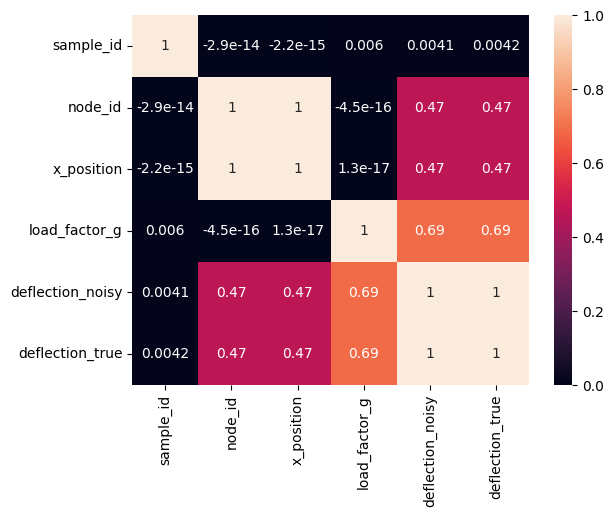

In [10]:
# find the correlation between columns in the dataset
sns.heatmap(flight_data.corr(), annot=True)

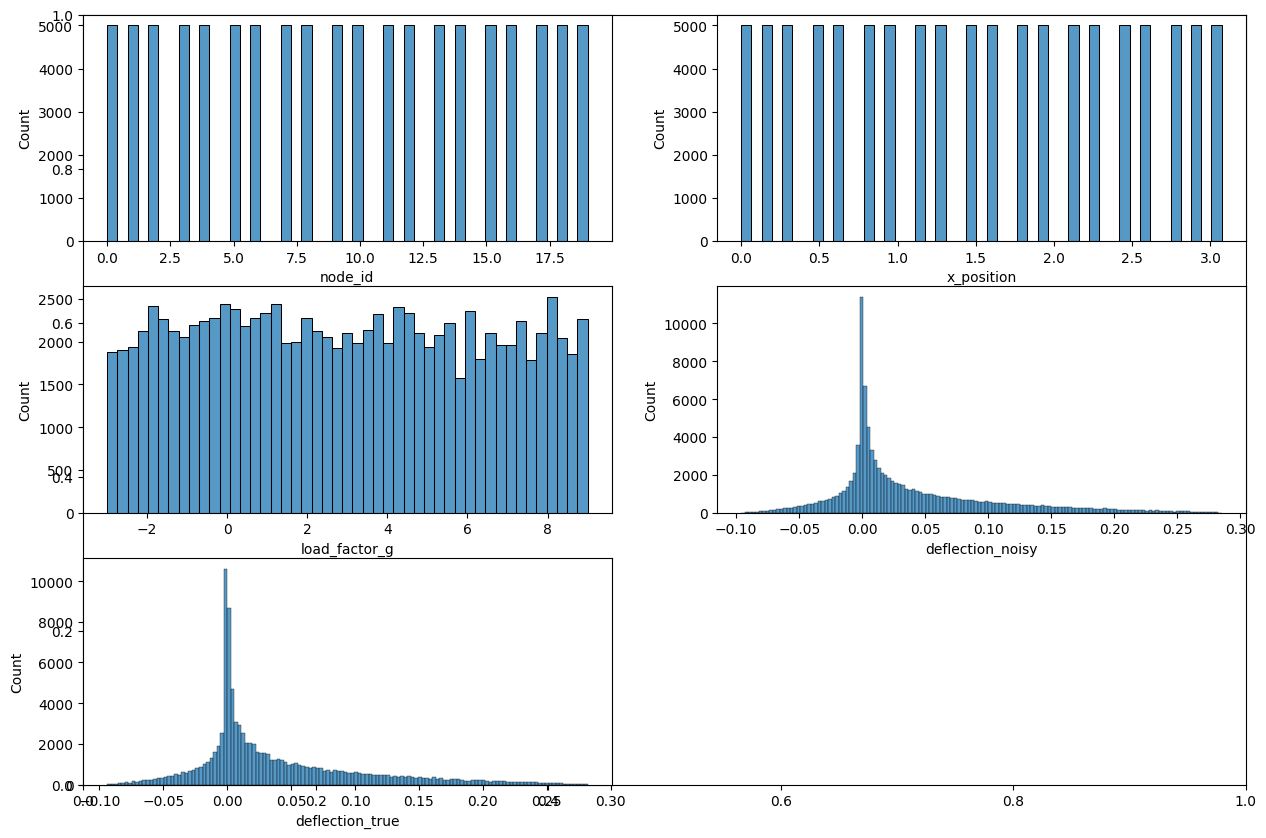

In [11]:
# explore the data distribution for the flight_data dataset
names = ['node_id', 'x_position', 'load_factor_g', 'deflection_noisy', 'deflection_true']
plt.subplots(figsize=(15, 10))
index = 1
for el in names:
    plt.subplot(3,2, index)
    sns.histplot(flight_data[el])
    index += 1

<Axes: xlabel='distance', ylabel='Count'>

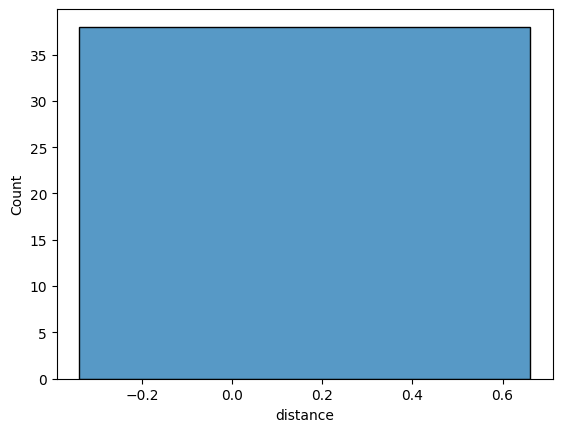

In [12]:
# explore distance distribution for the wing spar adjacency dataset
sns.histplot(wing_spar_adjacency['distance'])

In [13]:
flight_data.shape

(100000, 6)

In [14]:
wing_spar_adjacency.shape

(38, 3)